# Real Data Assessment: sPHENIX TPC
This notebook re-evaluates the dataset `clusters_seeds_island_79507-0.root_ntuplizer.root` recognizing it as **real detector data**, not a simulated dataset. 

In real data without Monte Carlo truth labels, variables like `hitID` are typically sequential indices or hardware identifiers, **not** particle/track labels. Therefore, we cannot group by `hitID` to find 'real tracks'. Instead, we must look at the physical properties of the hits (ADC, layer, spatial coordinates) and evaluate the overall data quality and occupancy before applying unsupervised clustering or tracking algorithms.

In [49]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjust plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [50]:
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
print(f"Loading real data sample from {file_path}...")

# Open the file and inspect the ntp_hit tree
try:
    with uproot.open(file_path) as f:
        hit_tree = f["ntp_hit"]
        print("Available branches in 'ntp_hit':", hit_tree.keys())
        
        # Load a standard set of columns. We'll start with hitID, adc, layer.
        # If spatial columns exist (like x, y, z, or r, phi), they will be useful later.
        branches_to_load = ["hitID", "adc", "layer"]
        
        # Check if they exist to avoid crashes
        valid_branches = [b for b in branches_to_load if b in hit_tree.keys()]
        print(valid_branches)
        data = hit_tree.arrays(valid_branches, library="pd")
        print(f"\nLoaded {len(data)} hits.")
except Exception as e:
    print("Error loading file or branches:", e)

data.head()

Loading real data sample from clusters_seeds_island_79507-0.root_ntuplizer.root...
Available branches in 'ntp_hit': ['event', 'seed', 'run', 'seg', 'job', 'hitID', 'e', 'adc', 'layer', 'phielem', 'zelem', 'cellID', 'ecell', 'phibin', 'zbin', 'tbin', 'phi', 'r', 'x', 'y', 'z', 'occ11', 'occ116', 'occ21', 'occ216', 'occ31', 'occ316', 'rawzdc', 'livezdc', 'scaledzdc', 'rawmbd', 'livembd', 'scaledmbd', 'rawmbdv10', 'livembdv10', 'scaledmbdv10', 'rawzdc1', 'livezdc1', 'scaledzdc1', 'rawmbd1', 'livembd1', 'scaledmbd1', 'rawmbdv101', 'livembdv101', 'scaledmbdv101', 'rzdc', 'rmbd', 'rmbdv10', 'bco1', 'bco', 'bcotr', 'bcotr1', 'ntrk', 'ntpcseed', 'nsiseed', 'nhitmvtx', 'nhitintt', 'nhittpot', 'nhittpcall', 'nhittpcin', 'nhittpcmid', 'nhittpcout', 'nclusall', 'nclustpc', 'nclustpcpos', 'nclustpcneg', 'nclusintt', 'nclusmaps', 'nclusmms']
['hitID', 'adc', 'layer']

Loaded 27532828 hits.


,hitID,adc,layer
0,17498220.0,0.0,0.0
1,17498222.0,0.0,0.0
2,17563756.0,0.0,0.0
3,17563758.0,0.0,0.0
4,17629292.0,0.0,0.0


### 1. Re-evaluating `hitID`
Let's check if `hitID` is simply a unique identifier per hit, rather than a grouping variable for tracks. If every row has a unique `hitID`, it means it's an index, not a particle ID.

In [51]:
if 'hitID' in data.columns:
    unique_ids = data['hitID'].nunique()
    total_hits = len(data)
    print(f"Total hits: {total_hits}")
    print(f"Unique hitIDs: {unique_ids}")
    
    if unique_ids == total_hits:
        print("\nConclusion: 'hitID' is a unique index for every single hit.")
        print("It cannot be used to group hits into tracks or calculate track multiplicity.")
    else:
        print("\nConclusion: 'hitID' has repeating values. Its meaning should be investigated (e.g., is it a cluster ID?).")
        print("Average hits per hitID:", total_hits / unique_ids)

Total hits: 27532828
Unique hitIDs: 644257

Conclusion: 'hitID' has repeating values. Its meaning should be investigated (e.g., is it a cluster ID?).
Average hits per hitID: 42.735784011659945


### 2. Physical Data Distributions
Instead of grouping by ID, we analyze the macroscopic properties of the event/data:
- **ADC Distribution**: Helps separate minimum ionizing particle (MIP) signals from low-energy electronics noise.
- **Hit Occupancy per Layer**: Shows detector activity, geometry coverage, and helps identify noisy layers.

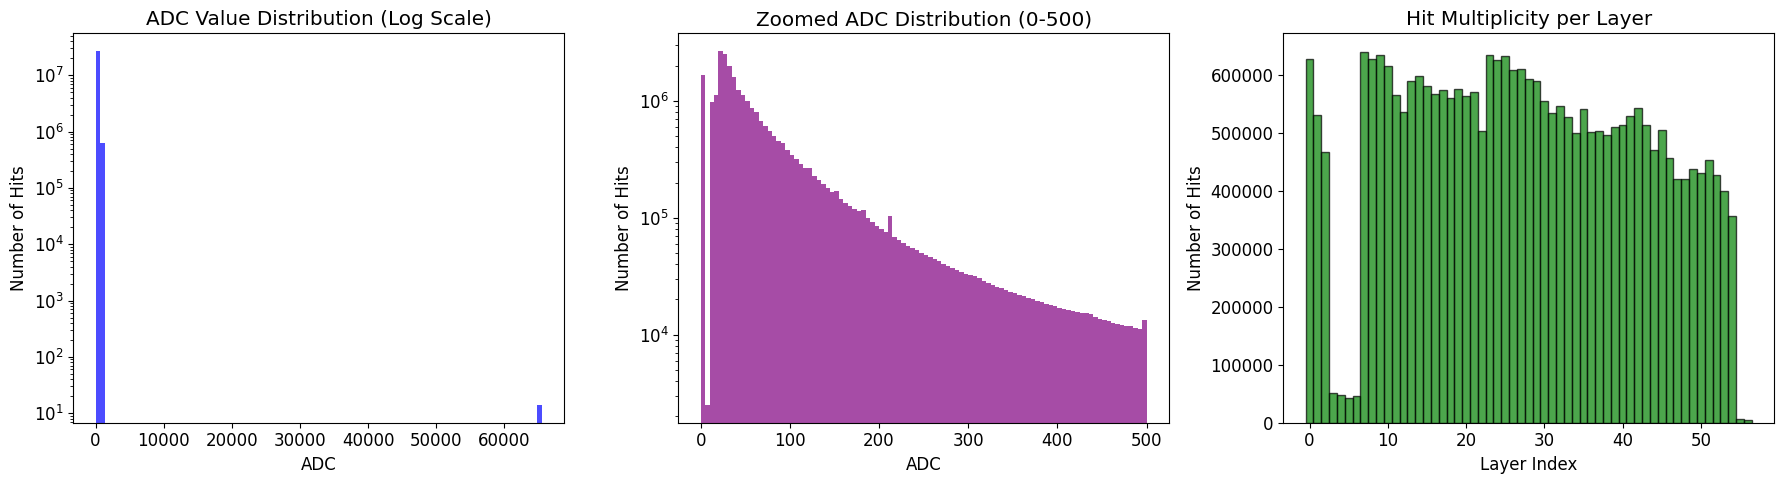

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'adc' in data.columns:
    axes[0].hist(data['adc'], bins=100, log=True, color='blue', alpha=0.7)
    axes[0].set_title("ADC Value Distribution (Log Scale)")
    axes[0].set_xlabel("ADC")
    axes[0].set_ylabel("Number of Hits")

    # Zoom in around 0 (e.g., up to 500)
    axes[1].hist(data['adc'], bins=100, range=(0, 500), log=True, color='purple', alpha=0.7)
    axes[1].set_title("Zoomed ADC Distribution (0-500)")
    axes[1].set_xlabel("ADC")
    axes[1].set_ylabel("Number of Hits")

if 'layer' in data.columns:
    axes[2].hist(data['layer'], bins=range(int(data['layer'].min()), int(data['layer'].max()) + 2), 
                 color='green', alpha=0.7, edgecolor='black', align='left')
    axes[2].set_title("Hit Multiplicity per Layer")
    axes[2].set_xlabel("Layer Index")
    axes[2].set_ylabel("Number of Hits")

plt.tight_layout()
plt.show()

### 3. Noise vs. Signal Separation Strategies in Real Data
Since we don't have simulated truth labels, we must rely on physical properties to identify signal from background and prepare for ML.

1. **ADC Thresholding**: Low ADC values often correspond to electronics noise. We can apply a threshold based on the distribution above to clean the data.
2. **Spatial Correlation (Clustering)**: Real tracks leave contiguous hits in adjacent layers and pads. We can use spatial clustering algorithms (like DBSCAN on physical coordinates $x, y, z$) to find contiguous hit structures.
3. **Track Finding**: Using classical tracking algorithms (e.g., Hough Transform) or Graph Neural Networks (GNNs) on the physical hit coordinates to identify track trajectories.

In [53]:
print("\n--- ML PREPROCESSING INSIGHTS FOR REAL DATA ---")
if 'adc' in data.columns:
    # Example threshold calculation (e.g., 90th percentile to isolate high-energy hits)
    adc_threshold = data['adc'].quantile(0.90)
    print(f"1. Suggested initial ADC threshold for noise reduction (e.g. 90th percentile): > {adc_threshold:.1f}")
    
print("2. Need to load spatial features (e.g., x, y, z or r, phi) to perform spatial clustering.")
print("3. Once spatial clusters/tracklets are formed, we can compute features like 'multiplicity' and 'layer_span' on THOSE structures, rather than arbitrary hitIDs.")


--- ML PREPROCESSING INSIGHTS FOR REAL DATA ---
1. Suggested initial ADC threshold for noise reduction (e.g. 90th percentile): > 196.0
2. Need to load spatial features (e.g., x, y, z or r, phi) to perform spatial clustering.
3. Once spatial clusters/tracklets are formed, we can compute features like 'multiplicity' and 'layer_span' on THOSE structures, rather than arbitrary hitIDs.


In [1]:
import uproot
import pandas as pd
import numpy as np

print("="*60)
print("     REAL DATASET ML ASSESSMENT (CORRECTING ASSUMPTIONS)      ")
print("="*60)

# In real data, 'hitID' in ntp_hit is a topological cluster/island ID, NOT a Geant4 track ID.
# Therefore, an island typically spans only 1-2 layers. The previous assumption that 
# valid tracks must have >= 4 hits in the same hitID is incorrect for real data.

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
tree_hit = uproot.open(file_path)["ntp_hit"]
tree_trk = uproot.open(file_path)["ntp_clus_trk"]

df_hit = tree_hit.arrays(["event", "hitID", "layer", "adc"], library="pd")
df_trk = tree_trk.arrays(["event", "seedID", "layer"], library="pd")

# Filter dead channels
df_hit = df_hit[df_hit["adc"] > 0]

print("\n1. Re-evaluating ntp_hit 'hitID' characteristics:")
hitid_layer_span = df_hit.groupby("hitID")["layer"].nunique()
# print(hitid_layer_span)
# hitid_layer_span.describe()
print(f"   Average layer span of a single hitID: {hitid_layer_span.mean():.2f} layers")
print(f"   Max layer span of a single hitID: {hitid_layer_span.max()} layers")
print("   -> Conclusion: hitID represents localized islands/clusters, not full tracks.")

print("\n2. Finding Pseudo-Ground Truth for ML in Real Data:")
# In real data, ntp_cluster and ntp_hit lack truth track IDs (e.g. trackID is NaN).
# However, ntp_clus_trk contains the clusters that were successfully fitted into tracks 
# by the classical tracking algorithm. These use 'seedID' to group clusters into tracks.

pseudo_tracks_span = df_trk.groupby(["event", "seedID"])["layer"].nunique()
pseudo_tracks_size = df_trk.groupby(["event", "seedID"]).size()

# print(pseudo_tracks_span)
# print(pseudo_tracks_size)

print(f"   Total classical tracks found in dataset: {len(pseudo_tracks_span):,}")
print(f"   Average clusters per classical track: {pseudo_tracks_size.mean():.1f}")
print(f"   Average layer span per classical track: {pseudo_tracks_span.mean():.1f} layers")
print(f"   Max layer span of a classical track: {pseudo_tracks_span.max()} layers")

print("\n3. Event-by-Event Real Data ML Audit:")
print("   Aggregating classical track (seedID) counts versus raw cluster counts...")

# Count valid classical tracks per event
valid_tracks_per_event = df_trk.groupby(["event", "seedID"]).size().reset_index().groupby("event").size()
# Count raw islands (hitIDs) per event
raw_islands_per_event = df_hit.groupby(["event", "hitID"]).size().reset_index().groupby("event").size()
total_hits_per_event = df_hit.groupby("event").size()

# print(valid_tracks_per_event)
# print(raw_islands_per_event)
# print(total_hits_per_event)

real_event_summary = pd.DataFrame({
    "total_active_hits": total_hits_per_event,
    "raw_islands": raw_islands_per_event,
    "valid_classical_tracks": valid_tracks_per_event
}).fillna(0).astype(int).reset_index()

for _, row in real_event_summary.iterrows():
    ev = row["event"]
    print(f"Analyzing Event {ev}: Total active hits = {row['total_active_hits']:,}")
    print(f"============================================================")
    print(f"             REAL DATA CLASSIFICATION SUMMARY             ")
    print(f"============================================================")
    print(f"Total Raw Islands (hitIDs) Found : {row['raw_islands']:,}")
    print(f"Valid Classical Tracks (seedIDs) : {row['valid_classical_tracks']:,}")
    print(f"------------------------------------------------------------\n")

output_csv = "real_data_event_summary.csv"
real_event_summary.to_csv(output_csv, index=False)
print(f"Global real-data cross-event summary saved successfully to '{output_csv}'.")

print("\n4. ML Training Strategy for this Real Dataset:")
print("   - Do NOT use ntp_hit 'hitID' as track labels.")
print("   - Use 'ntp_clus_trk' (grouped by 'seedID') to define the positive/signal track class (Pseudo-Truth).")
print("   - Map spatial coordinates (x, y, z) from ntp_clus_trk back to ntp_hit to label the raw hits as 'Tracked' (Signal) vs 'Untracked' (Noise).")
print("   - This provides a realistic binary classification target for ML models.")
print("="*60)


     REAL DATASET ML ASSESSMENT (CORRECTING ASSUMPTIONS)      

1. Re-evaluating ntp_hit 'hitID' characteristics:
   Average layer span of a single hitID: 16.75 layers
   Max layer span of a single hitID: 45 layers
   -> Conclusion: hitID represents localized islands/clusters, not full tracks.

2. Finding Pseudo-Ground Truth for ML in Real Data:
   Total classical tracks found in dataset: 6,138
   Average clusters per classical track: 36.1
   Average layer span per classical track: 36.1 layers
   Max layer span of a classical track: 48 layers

3. Event-by-Event Real Data ML Audit:
   Aggregating classical track (seedID) counts versus raw cluster counts...
Analyzing Event 1.0: Total active hits = 58,339.0
             REAL DATA CLASSIFICATION SUMMARY             
Total Raw Islands (hitIDs) Found : 23,825.0
Valid Classical Tracks (seedIDs) : 26.0
------------------------------------------------------------

Analyzing Event 2.0: Total active hits = 197,229.0
             REAL DATA CLASSIF

### 4. Interactive Data Labeling using Plotly FigureWidget
To create training labels manually, we can plot a subset of our data (e.g., high ADC hits) in 3D and interactively click on them to label them as 'signal' or 'noise'.

In [55]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. Create a dummy dataframe for demonstration (replace with actual spatial data if loaded)
df_sample = pd.DataFrame({
    'x': np.random.rand(100) * 100,
    'y': np.random.rand(100) * 100,
    'z': np.random.rand(100) * 100,
    'label': ['unknown'] * 100  # Initial state
})

# 2. MUST use FigureWidget for Python callbacks to work in Jupyter
fig = go.FigureWidget()

# 3. Add the 3D scatter trace
fig.add_trace(go.Scatter3d(
    x=df_sample['x'], 
    y=df_sample['y'], 
    z=df_sample['z'],
    mode='markers',
    marker=dict(size=4, color=['gray'] * len(df_sample)), # Explicit color array needed for indexed updates
    # Store the DataFrame index in customdata so we know EXACTLY which row we clicked
    customdata=df_sample.index, 
    hoverinfo='text',
    text=[f"Index: {i}<br>Label: unknown" for i in df_sample.index]
))

scatter_trace = fig.data[0]

# 4. Define the Python function that runs when a point is clicked
def on_point_click(trace, points, selector):
    if not points.point_inds:
        return
    
    point_idx = points.point_inds[0]
    df_row_idx = trace.customdata[point_idx]
    
    current_label = df_sample.loc[df_row_idx, 'label']
    
    if current_label == 'unknown':
        new_label = 'signal'
        new_color = 'red'
    elif current_label == 'signal':
        new_label = 'noise'
        new_color = 'blue'
    else:
        new_label = 'unknown'
        new_color = 'gray'
        
    df_sample.loc[df_row_idx, 'label'] = new_label
    
    colors = list(trace.marker.color)
    colors[point_idx] = new_color
    
    hover_texts = list(trace.text)
    hover_texts[point_idx] = f"Index: {df_row_idx}<br>Label: {new_label}"
    
    with fig.batch_update():
        trace.marker.color = colors
        trace.text = hover_texts

# 5. Attach the callback to the trace
scatter_trace.on_click(on_point_click)

# 6. Display the widget
fig


FigureWidget({
    'data': [{'customdata': {'bdata': ('AAECAwQFBgcICQoLDA0ODxAREhMUFR' ... '9QUVJTVFVWV1hZWltcXV5fYGFiYw=='),
                             'dtype': 'i1'},
              'hoverinfo': 'text',
              'marker': {'color': [gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, gray, gray, gray, gray, gray, gray,
                                   gray, gray, 

### 5. Central Data Loader
Run this cell **ONCE** to load the data into memory. The interactive labeling cells below (5a, 5b, 5c) will all share this same memory, meaning your labels will persist as you switch between different views!

In [56]:
import uproot
import pandas as pd
import numpy as np

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
print("Loading real data for interactive labeling...")
with uproot.open(file_path) as f:
    hit_tree = f["ntp_hit"]
    df_real = hit_tree.arrays(["event", "hitID", "layer", "phi", "tbin", "x", "y", "z", "adc"], library="pd")

df_real['label'] = 'unknown'
df_real['color'] = 'gray'

# Pre-compute transformed coordinates for view 5b
df_real['trans_x'] = df_real['layer'] * np.cos(df_real['phi'])
df_real['trans_y'] = df_real['layer'] * np.sin(df_real['phi'])

print(f"Successfully loaded {len(df_real)} hits. Ready for labeling!")

Loading real data for interactive labeling...
Successfully loaded 27532828 hits. Ready for labeling!


### 5a. Advanced Interactive Labeling (2D Selection Linked to 3D)
Plotly 3D scatter plots do not support lasso or box selection. To select many points at once, we can plot a 2D projection (e.g., X vs Y) next to the 3D plot. 
You can use the **Lasso Select** or **Box Select** tools on the 2D plot, and it will update the 3D plot and your underlying DataFrame automatically.

In [57]:
import plotly.graph_objects as go
import ipywidgets as widgets
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets

# 2. Create the 3D FigureWidget
fig3d = go.FigureWidget()
scatter3d = go.Scatter3d(
    mode='markers',
    marker=dict(size=3),
    hoverinfo='text'
)
fig3d.add_trace(scatter3d)
fig3d.update_layout(title="3D View (Selected Event & Layer)", margin=dict(l=0, r=0, b=0, t=40), scene=dict(aspectmode='data'))

# 3. Create the 2D FigureWidget (X vs Y projection)
fig2d = go.FigureWidget()
scatter2d = go.Scatter(
    mode='markers',
    marker=dict(size=5),
    hoverinfo='text'
)
fig2d.add_trace(scatter2d)
# Enable lasso by default
fig2d.update_layout(title="2D Slice: X vs Y", dragmode='lasso', margin=dict(l=0, r=0, b=0, t=40), xaxis_title="X", yaxis_title="Y")

trace3d = fig3d.data[0]
trace2d = fig2d.data[0]

# 4. Selectors (Event & Layer)
available_events = sorted(df_real['event'].unique().astype(int))
event_dropdown = widgets.Dropdown(
    options=available_events,
    value=available_events[0],
    description='Event:'
)

available_layers = sorted(df_real['layer'].unique().astype(int))
layer_dropdown = widgets.Dropdown(
    options=available_layers,
    value=available_layers[0],
    description='Layer:'
)

# Function to update plots when dropdowns change
def update_plots(*args):
    current_event = event_dropdown.value
    current_layer = layer_dropdown.value
    
    # Filter data for the current event AND layer
    df_slice = df_real[(df_real['event'] == current_event) & (df_real['layer'] == current_layer)]
    
    with fig3d.batch_update():
        trace3d.x = df_slice['x']
        trace3d.y = df_slice['y']
        trace3d.z = df_slice['z']
        trace3d.marker.color = df_slice['color'].tolist()
        trace3d.customdata = df_slice.index
        trace3d.text = [f"Index: {i}<br>ADC: {adc:.1f}<br>Label: {lbl}" for i, adc, lbl in zip(df_slice.index, df_slice['adc'], df_slice['label'])]
        
    with fig2d.batch_update():
        trace2d.x = df_slice['x']
        trace2d.y = df_slice['y']
        trace2d.marker.color = df_slice['color'].tolist()
        trace2d.customdata = df_slice.index
        trace2d.text = [f"Index: {i}<br>ADC: {adc:.1f}<br>Label: {lbl}" for i, adc, lbl in zip(df_slice.index, df_slice['adc'], df_slice['label'])]

# Trigger update when EITHER dropdown changes
event_dropdown.observe(update_plots, 'value')
layer_dropdown.observe(update_plots, 'value')

# 5. Callbacks for Selection and Clicking
def update_labels_and_colors(points, new_label, new_color):
    if not points.point_inds:
        return
    
    # We update the main dataframe directly using the customdata (DataFrame index)
    for idx in points.point_inds:
        df_row_idx = trace2d.customdata[idx]
        df_real.loc[df_row_idx, 'label'] = new_label
        df_real.loc[df_row_idx, 'color'] = new_color

    # Refresh the plot views
    update_plots()

def on_selection(trace, points, selector):
    if not points.point_inds:
        return
    for idx in points.point_inds:
        df_row_idx = trace.customdata[idx]
        current_label = df_real.loc[df_row_idx, 'label']
        if current_label == 'unknown':
            df_real.loc[df_row_idx, 'label'] = 'signal'
            df_real.loc[df_row_idx, 'color'] = 'red'
        elif current_label == 'signal':
            df_real.loc[df_row_idx, 'label'] = 'noise'
            df_real.loc[df_row_idx, 'color'] = 'blue'
        else:
            df_real.loc[df_row_idx, 'label'] = 'unknown'
            df_real.loc[df_row_idx, 'color'] = 'gray'
    update_plots()


def on_click(trace, points, selector):
    if not points.point_inds:
        return
    
    idx = points.point_inds[0]
    df_row_idx = trace.customdata[idx]
    current_label = df_real.loc[df_row_idx, 'label']
    
    if current_label == 'unknown':
        update_labels_and_colors(points, 'signal', 'red')
    elif current_label == 'signal':
        update_labels_and_colors(points, 'noise', 'blue')
    else:
        update_labels_and_colors(points, 'unknown', 'gray')

trace2d.on_selection(on_selection)
trace2d.on_click(on_click)
trace3d.on_click(on_click)

# Initialize plots with the first event/layer combo
update_plots()

# 6. Display UI
ui = widgets.VBox([
    widgets.HBox([event_dropdown, layer_dropdown]),
    widgets.HBox([fig2d, fig3d])
])
display(ui)


### 5b. Interactive Labeling with Transformed Coordinates (Radius, Phi, Tbin)
This cell applies the physical transformation:
- `X = layer * cos(phi)`
- `Y = layer * sin(phi)`
- `Z = tbin`

It provides a much narrower Z-span for visualization.

In [46]:
import plotly.graph_objects as go
import ipywidgets as widgets
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets

# 2. Create the 3D FigureWidget
fig3d = go.FigureWidget()
scatter3d = go.Scatter3d(
    mode='markers',
    marker=dict(size=3),
    hoverinfo='text'
)
fig3d.add_trace(scatter3d)
fig3d.update_layout(title="3D View (Transformed: X/Y=r*phi, Z=tbin)", margin=dict(l=0, r=0, b=0, t=40), scene=dict(aspectmode='data'))

# 3. Create the 2D FigureWidget (X vs Y projection)
fig2d = go.FigureWidget()
scatter2d = go.Scatter(
    mode='markers',
    marker=dict(size=5),
    hoverinfo='text'
)
fig2d.add_trace(scatter2d)
# Enable lasso by default
fig2d.update_layout(title="2D Slice: X vs Y", dragmode='lasso', margin=dict(l=0, r=0, b=0, t=40), xaxis_title="X", yaxis_title="Y")

trace3d = fig3d.data[0]
trace2d = fig2d.data[0]

# 4. Selectors (Event & Layer)
available_events = sorted(df_real['event'].unique().astype(int))
event_dropdown = widgets.Dropdown(
    options=available_events,
    value=available_events[0],
    description='Event:'
)

available_layers = sorted(df_real['layer'].unique().astype(int))
layer_dropdown = widgets.Dropdown(
    options=available_layers,
    value=available_layers[0],
    description='Layer:'
)

# Function to update plots when dropdowns change
def update_plots(*args):
    current_event = event_dropdown.value
    current_layer = layer_dropdown.value
    
    # Filter data for the current event AND layer
    df_slice = df_real[(df_real['event'] == current_event) & (df_real['layer'] == current_layer)]
    
    with fig3d.batch_update():
        trace3d.x = df_slice['trans_x']
        trace3d.y = df_slice['trans_y']
        trace3d.z = df_slice['tbin']
        trace3d.marker.color = df_slice['color'].tolist()
        trace3d.customdata = df_slice.index
        trace3d.text = [f"Index: {i}<br>ADC: {adc:.1f}<br>Label: {lbl}" for i, adc, lbl in zip(df_slice.index, df_slice['adc'], df_slice['label'])]
        
    with fig2d.batch_update():
        trace2d.x = df_slice['trans_x']
        trace2d.y = df_slice['trans_y']
        trace2d.marker.color = df_slice['color'].tolist()
        trace2d.customdata = df_slice.index
        trace2d.text = [f"Index: {i}<br>ADC: {adc:.1f}<br>Label: {lbl}" for i, adc, lbl in zip(df_slice.index, df_slice['adc'], df_slice['label'])]

# Trigger update when EITHER dropdown changes
event_dropdown.observe(update_plots, 'value')
layer_dropdown.observe(update_plots, 'value')

# 5. Callbacks for Selection and Clicking
def update_labels_and_colors(points, new_label, new_color):
    if not points.point_inds:
        return
    
    # We update the main dataframe directly using the customdata (DataFrame index)
    for idx in points.point_inds:
        df_row_idx = trace2d.customdata[idx]
        df_real.loc[df_row_idx, 'label'] = new_label
        df_real.loc[df_row_idx, 'color'] = new_color

    # Refresh the plot views
    update_plots()

def on_selection(trace, points, selector):
    if not points.point_inds:
        return
    for idx in points.point_inds:
        df_row_idx = trace.customdata[idx]
        current_label = df_real.loc[df_row_idx, 'label']
        if current_label == 'unknown':
            df_real.loc[df_row_idx, 'label'] = 'signal'
            df_real.loc[df_row_idx, 'color'] = 'red'
        elif current_label == 'signal':
            df_real.loc[df_row_idx, 'label'] = 'noise'
            df_real.loc[df_row_idx, 'color'] = 'blue'
        else:
            df_real.loc[df_row_idx, 'label'] = 'unknown'
            df_real.loc[df_row_idx, 'color'] = 'gray'
    update_plots()


def on_click(trace, points, selector):
    if not points.point_inds:
        return
    
    idx = points.point_inds[0]
    df_row_idx = trace.customdata[idx]
    current_label = df_real.loc[df_row_idx, 'label']
    
    if current_label == 'unknown':
        update_labels_and_colors(points, 'signal', 'red')
    elif current_label == 'signal':
        update_labels_and_colors(points, 'noise', 'blue')
    else:
        update_labels_and_colors(points, 'unknown', 'gray')

trace2d.on_selection(on_selection)
trace2d.on_click(on_click)
trace3d.on_click(on_click)

# Initialize plots with the first event/layer combo
update_plots()

# 6. Display UI
ui = widgets.VBox([
    widgets.HBox([event_dropdown, layer_dropdown]),
    widgets.HBox([fig2d, fig3d])
])
display(ui)


### 5c. Interactive Labeling (Axes: Layer, Phi, Tbin)
This view plots the variables directly on the axes (`X=Layer`, `Y=Phi`, `Z=Tbin`). When you hover over a point, it displays its physical `x`, `y`, `z` coordinates from the original tree.

In [47]:
import plotly.graph_objects as go
import ipywidgets as widgets
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import ipywidgets as widgets

# 2. Create the 3D FigureWidget
fig3d = go.FigureWidget()
scatter3d = go.Scatter3d(
    mode='markers',
    marker=dict(size=3),
    hoverinfo='text'
)
fig3d.add_trace(scatter3d)
fig3d.update_layout(
    title="3D View (X=Layer, Y=Phi, Z=Tbin)", 
    margin=dict(l=0, r=0, b=0, t=40), 
    scene=dict(
        xaxis_title='Layer',
        yaxis_title='Phi',
        zaxis_title='Tbin',
        aspectmode='data'
    )
)

# 3. Create the 2D FigureWidget (Phi vs Tbin for the selected layer)
fig2d = go.FigureWidget()
scatter2d = go.Scatter(
    mode='markers',
    marker=dict(size=5),
    hoverinfo='text'
)
fig2d.add_trace(scatter2d)
fig2d.update_layout(title="2D Slice: Phi vs Tbin", dragmode='lasso', margin=dict(l=0, r=0, b=0, t=40), xaxis_title="Phi", yaxis_title="Tbin")

trace3d = fig3d.data[0]
trace2d = fig2d.data[0]

# 4. Selectors (Event & Layer)
available_events = sorted(df_real['event'].unique().astype(int))
event_dropdown = widgets.Dropdown(options=available_events, value=available_events[0], description='Event:')

available_layers = sorted(df_real['layer'].unique().astype(int))
layer_dropdown = widgets.Dropdown(options=available_layers, value=available_layers[0], description='Layer:')

def update_plots(*args):
    current_event = event_dropdown.value
    current_layer = layer_dropdown.value
    
    df_slice = df_real[(df_real['event'] == current_event) & (df_real['layer'] == current_layer)]
    
    # Construct hover text with x, y, z included
    hover_text = [
        f"Index: {i}<br>ADC: {row.adc:.1f}<br>x: {row.x:.2f}<br>y: {row.y:.2f}<br>z: {row.z:.2f}<br>Label: {row.label}"
        for i, row in df_slice.iterrows()
    ]
    
    with fig3d.batch_update():
        trace3d.x = df_slice['layer']
        trace3d.y = df_slice['phi']
        trace3d.z = df_slice['tbin']
        trace3d.marker.color = df_slice['color'].tolist()
        trace3d.customdata = df_slice.index
        trace3d.text = hover_text
        
    with fig2d.batch_update():
        trace2d.x = df_slice['phi']
        trace2d.y = df_slice['tbin']
        trace2d.marker.color = df_slice['color'].tolist()
        trace2d.customdata = df_slice.index
        trace2d.text = hover_text

event_dropdown.observe(update_plots, 'value')
layer_dropdown.observe(update_plots, 'value')

def update_labels_and_colors(points, new_label, new_color):
    if not points.point_inds:
        return
    for idx in points.point_inds:
        df_row_idx = trace2d.customdata[idx]
        df_real.loc[df_row_idx, 'label'] = new_label
        df_real.loc[df_row_idx, 'color'] = new_color
    update_plots()

def on_selection(trace, points, selector):
    if not points.point_inds:
        return
    for idx in points.point_inds:
        df_row_idx = trace.customdata[idx]
        current_label = df_real.loc[df_row_idx, 'label']
        if current_label == 'unknown':
            df_real.loc[df_row_idx, 'label'] = 'signal'
            df_real.loc[df_row_idx, 'color'] = 'red'
        elif current_label == 'signal':
            df_real.loc[df_row_idx, 'label'] = 'noise'
            df_real.loc[df_row_idx, 'color'] = 'blue'
        else:
            df_real.loc[df_row_idx, 'label'] = 'unknown'
            df_real.loc[df_row_idx, 'color'] = 'gray'
    update_plots()


def on_click(trace, points, selector):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    df_row_idx = trace.customdata[idx]
    current_label = df_real.loc[df_row_idx, 'label']
    
    if current_label == 'unknown':
        update_labels_and_colors(points, 'signal', 'red')
    elif current_label == 'signal':
        update_labels_and_colors(points, 'noise', 'blue')
    else:
        update_labels_and_colors(points, 'unknown', 'gray')

trace2d.on_selection(on_selection)
trace2d.on_click(on_click)
trace3d.on_click(on_click)

update_plots()

ui = widgets.VBox([
    widgets.HBox([event_dropdown, layer_dropdown]),
    widgets.HBox([fig2d, fig3d])
])
display(ui)


### 6. Export Labeled Data
Once you have labeled some points as 'signal' or 'noise', run the cell below to export them to a CSV file. It drops 'unknown' points and saves all loaded branch properties (including `hitID` and `event`) so you can link them back to the original `.root` tree if needed.

In [48]:
import os

# Filter out points that haven't been labeled
labeled_df = df_real[df_real['label'] != 'unknown'].copy()

if len(labeled_df) > 0:
    # Remove the UI color column before saving
    if 'color' in labeled_df.columns:
        labeled_df = labeled_df.drop(columns=['color'])
        
    output_csv = 'labeled_hits.csv'
    labeled_df.to_csv(output_csv, index=False)
    print(f"Successfully saved {len(labeled_df)} labeled hits to '{output_csv}'")
    display(labeled_df.head())
else:
    print("No points have been labeled yet. Please select some points as 'signal' or 'noise' in the interactive plots above.")

Successfully saved 81 labeled hits to 'labeled_hits.csv'


,event,hitID,layer,phi,tbin,x,y,z,adc,label,trans_x,trans_y
19495,1.0,47972372.0,9.0,-1.191074,19.0,12.094843,-30.305996,8.324736,49.0,noise,3.335963,-8.358909
19496,1.0,47972372.0,9.0,-1.191074,20.0,12.094843,-30.305996,8.748142,106.0,noise,3.335963,-8.358909
19497,1.0,47972372.0,9.0,-1.191074,21.0,12.094843,-30.305996,9.171550,31.0,noise,3.335963,-8.358909
19498,1.0,48037908.0,9.0,-1.196381,19.0,11.933830,-30.369761,8.324736,39.0,noise,3.291553,-8.376495
19499,1.0,48037908.0,9.0,-1.196381,20.0,11.933830,-30.369761,8.748142,117.0,noise,3.291553,-8.376495


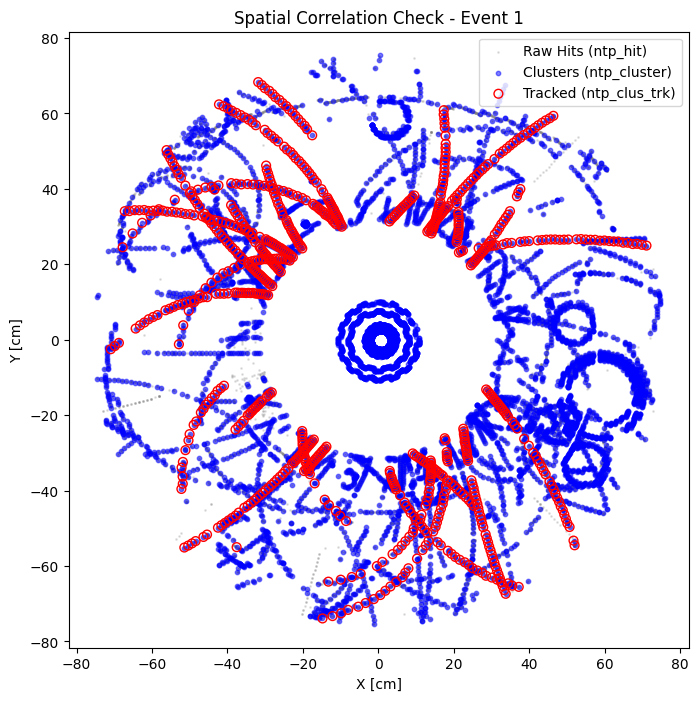

In [1]:
#   ntp_cluser && ntp_clus_trk Correlation Check:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
# Select Event 1 as an exhibition
ev = 1 
with uproot.open(file_path) as f:
    h = f["ntp_hit"].arrays(["x", "y"], cut=f"event=={ev}")
    c = f["ntp_cluster"].arrays(["x", "y"], cut=f"event=={ev}")
    t = f["ntp_clus_trk"].arrays(["x", "y"], cut=f"event=={ev}")

plt.figure(figsize=(8, 8))
plt.scatter(h.x, h.y, s=1, c='gray', alpha=0.2, label="Raw Hits (ntp_hit)")
plt.scatter(c.x, c.y, s=10, c='blue', alpha=0.5, label="Clusters (ntp_cluster)")
plt.scatter(t.x, t.y, s=40, edgecolors='red', facecolors='none', label="Tracked (ntp_clus_trk)")

plt.title(f"Spatial Correlation Check - Event {ev}")
plt.xlabel("X [cm]")
plt.ylabel("Y [cm]")
plt.legend()
plt.axis('equal')
plt.savefig(f"./Visualizing/images/spatial_correlation_Event{ev}.png")

Numerical Check for Event 1:
  Signal Hits found: 72649
  Track Clusters found: 837


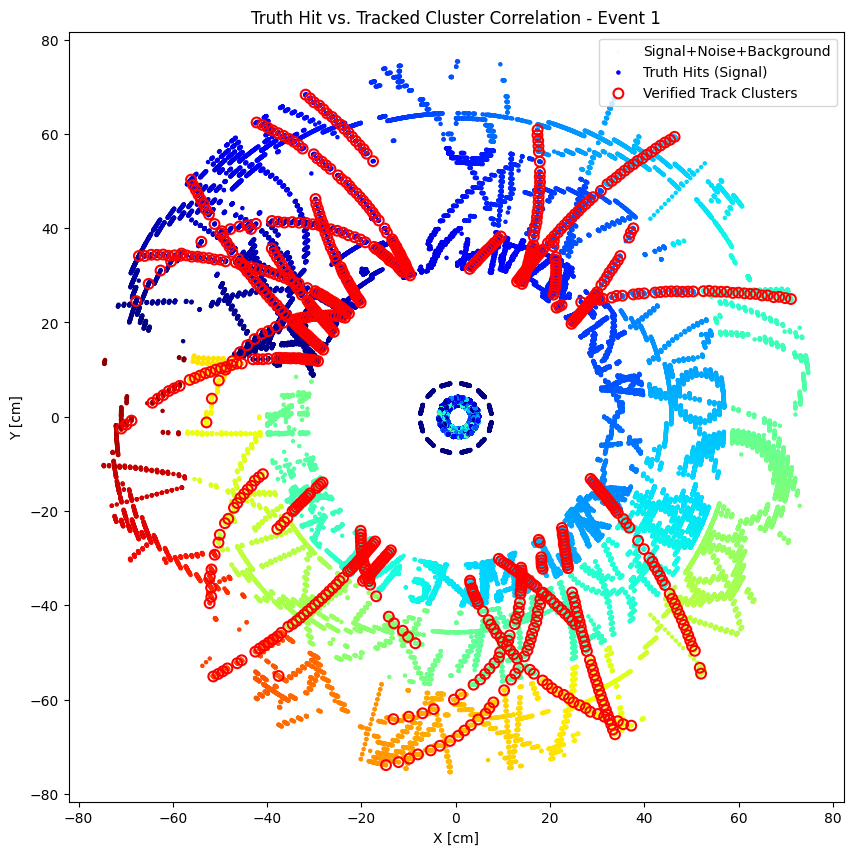

In [6]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"
with uproot.open(file_path) as f:
    # Load Event 1 (known to have data)
    ev = 1
    # Get Real Hits
    hits = f["ntp_hit"].arrays(["x", "y", "z", "hitID"], cut=f"event=={ev}")
    # Get Reconstructed Tracks
    tracks = f["ntp_clus_trk"].arrays(["x", "y", "z"], cut=f"event=={ev}")

# Filter hits to only show Signal (hitID > 0)
signal_hits = hits[hits.hitID > 0]

# --- Visualization ---
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. Plot all Raw Hits in light gray
ax.scatter(hits.x, hits.y, s=1, c='lightgray', alpha=0.1, label="Signal+Noise+Background")

# 2. Plot Signal Hits (Truth) colored by hitID
scatter = ax.scatter(signal_hits.x, signal_hits.y, s=5, c=signal_hits.hitID, 
                     cmap='jet', label="Truth Hits (Signal)")

# 3. Overlay the Tracked Clusters as open red circles
ax.scatter(tracks.x, tracks.y, s=50, facecolors='none', edgecolors='red', 
           linewidth=1.5, label="Verified Track Clusters")

ax.set_xlabel("X [cm]")
ax.set_ylabel("Y [cm]")
ax.set_title(f"Truth Hit vs. Tracked Cluster Correlation - Event {ev}")
ax.legend(loc='upper right')
plt.axis('equal')
plt.savefig(f"./Visualizing/images/spatial_trk_check_Event{ev}.png")

# --- Numerical Consistency Check ---
# Check if a track cluster exists where there are no truth hits
print(f"Numerical Check for Event {ev}:")
print(f"  Signal Hits found: {len(signal_hits)}")
print(f"  Track Clusters found: {len(tracks)}")

In [7]:
import uproot
import pandas as pd

# Define the path to your ROOT file
file_path = "clusters_seeds_island_79507-0.root_ntuplizer.root"

print("Loading ROOT file...")
with uproot.open(file_path) as root_file:
    
    # 1. Load the ntp_info tree (Global Event level)
    # We load 'event' and 'occ11' to see the macroscopic occupancy
    df_info = root_file["ntp_info"].arrays(["event", "occ11"], library="pd")
    
    # 2. Load the ntp_cluster tree (Local Cluster level)
    # We load a subset of columns to save memory
    df_cluster = root_file["ntp_cluster"].arrays(["event", "occ11"], library="pd")

print("\n--- TEST 1: Are 'occ' values constant for all clusters inside a single event? ---")
# Group clusters by their event ID, and count the number of UNIQUE occ11 values per event
unique_occ_per_event = df_cluster.groupby('event')['occ11'].nunique()

# If occ11 is a global feature, every event should have exactly 1 unique occ11 value across all its clusters
if (unique_occ_per_event == 1).all():
    print("✅ SUCCESS: Every single cluster within the same event has the exact same 'occ11' value. It does not vary hit-by-hit.")
else:
    print("❌ FAILED: Found varying 'occ11' values within the same event.")


print("\n--- TEST 2: Do the cluster-level 'occ' values match the global 'ntp_info' values? ---")
# Grab the first 3 event IDs to compare
sample_events = df_info['event'].head(100).values

for ev in sample_events:
    # Extract the macroscopic occupancy from ntp_info
    info_occ11 = df_info[df_info['event'] == ev]['occ11'].iloc[0]
    
    # Extract the occupancy from the clusters in ntp_cluster
    cluster_subset = df_cluster[df_cluster['event'] == ev]
    cluster_occ11 = cluster_subset['occ11'].iloc[0]
    num_clusters = len(cluster_subset)
    
    print(f"Event {ev}:")
    print(f"  -> Total clusters in this event: {num_clusters}")
    print(f"  -> occ11 value in ntp_info:      {info_occ11}")
    print(f"  -> occ11 value in ntp_cluster:   {cluster_occ11}")
    print(f"  -> Match? {'✅ Yes' if info_occ11 == cluster_occ11 else '❌ No'}\n")

Loading ROOT file...

--- TEST 1: Are 'occ' values constant for all clusters inside a single event? ---
✅ SUCCESS: Every single cluster within the same event has the exact same 'occ11' value. It does not vary hit-by-hit.

--- TEST 2: Do the cluster-level 'occ' values match the global 'ntp_info' values? ---
Event 1.0:
  -> Total clusters in this event: 9712
  -> occ11 value in ntp_info:      0.0008977795368991792
  -> occ11 value in ntp_cluster:   0.0008977795368991792
  -> Match? ✅ Yes

Event 2.0:
  -> Total clusters in this event: 25645
  -> occ11 value in ntp_info:      0.0033816073555499315
  -> occ11 value in ntp_cluster:   0.0033816073555499315
  -> Match? ✅ Yes

Event 3.0:
  -> Total clusters in this event: 17133
  -> occ11 value in ntp_info:      0.0023600261192768812
  -> occ11 value in ntp_cluster:   0.0023600261192768812
  -> Match? ✅ Yes

Event 4.0:
  -> Total clusters in this event: 17407
  -> occ11 value in ntp_info:      0.002560013672336936
  -> occ11 value in ntp_cluste